# Show Results

This notebook loads the `results/*_bsf_trajectories.csv` files and plots the best-so-far trajectories for each benchmark dataset.


In [13]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use('seaborn-v0_8-white')
plt.rcParams['figure.dpi'] = 140
plt.rcParams['axes.grid'] = False
plt.rcParams['axes.spines.top'] = True
plt.rcParams['axes.spines.right'] = True
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.bottom'] = True

FRAME_COLOR = '#333333'


def find_repo_root() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [cwd, *cwd.parents]
    for candidate in candidates:
        if (candidate / 'results').exists() and (candidate / 'data').exists():
            return candidate
    raise FileNotFoundError('Could not locate repo root containing both results and data directories.')


REPO_ROOT = find_repo_root()
RESULTS_DIR = REPO_ROOT / 'results'
PLOT_RESULTS_DIR = REPO_ROOT / 'plot' / 'results'
PLOT_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
CSV_PATHS = sorted(RESULTS_DIR.glob('*_bsf_trajectories.csv'))

METHOD_ORDER = [
    'ChemBO',
    'Reasoning BO',
    'Pure AutoBO',
    'Pure Reasoning',
    'Random Search',
    'BORA',
    'CAKE',
    'GoLLuM',
    'HEBO',
    'LMABO',
]

REFERENCE_METHOD_COLORS = {
    'C1G8': 'red',
    'C3G6': 'orange',
    'CatBOX': '#FF6B6B',
    'C7G2': 'green',
    'CAS': 'cyan',
    'COCABO': '#D797B9',
    'MVRSM': '#1AA6A1',
    'TPE': '#F1A208',
    'EDBO': 'pink',
    'GPyOpt': '#2F7BFF',
    'RS': '#A88BEB',
    'SMKBO': '#32CD32',
    'Gryffin': '#F4D03F',
}

MACARON_METHOD_COLORS = {
    **REFERENCE_METHOD_COLORS,
    'ChemBO': 'red',
    'Reasoning BO': REFERENCE_METHOD_COLORS['GPyOpt'],
    'Pure AutoBO': REFERENCE_METHOD_COLORS['MVRSM'],
    'Pure Reasoning': REFERENCE_METHOD_COLORS['TPE'],
    'Random Search': REFERENCE_METHOD_COLORS['RS'],
    'BORA': REFERENCE_METHOD_COLORS['COCABO'],
    'CAKE': REFERENCE_METHOD_COLORS['CatBOX'],
    'GoLLuM': REFERENCE_METHOD_COLORS['SMKBO'],
    'HEBO': REFERENCE_METHOD_COLORS['CAS'],
    'LMABO': REFERENCE_METHOD_COLORS['Gryffin'],
}

DATASET_CONFIG = {
    'DAR': {
        'data_path': REPO_ROOT / 'data' / 'DAR.csv',
        'target_column': 'yield',
    },
    'OCM': {
        'data_path': REPO_ROOT / 'data' / 'OCM.csv',
        'target_column': 'Performance',
    },
    'OER': {
        'data_path': REPO_ROOT / 'data' / 'OER.csv',
        'target_column': 'objective',
    },
    'Suzuki': {
        'data_path': REPO_ROOT / 'data' / 'suzuki.csv',
        'target_column': 'Product_Yield_PCT_Area_UV',
    },
}

DATASET_VALUE_SHIFT = {
    'OER': 0.75,
}


def dataset_plot_dir(dataset):
    out_dir = PLOT_RESULTS_DIR / dataset
    out_dir.mkdir(parents=True, exist_ok=True)
    return out_dir


def save_figure(fig, path, *, dpi=300):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, dpi=dpi, bbox_inches='tight')



def save_method_legend(*, colors=None, path=None, ncol=3):
    colors = colors or MACARON_METHOD_COLORS
    path = Path(path or (PLOT_RESULTS_DIR / 'method_legend.png'))
    fig, ax = plt.subplots(figsize=(8.5, 2.8))
    handles = []
    labels = []
    for method in METHOD_ORDER:
        if method not in colors:
            continue
        handle = plt.Line2D([0], [0], color=colors[method], linewidth=4.0 if method == 'ChemBO' else 2.5)
        handles.append(handle)
        labels.append(method)
    ax.axis('off')
    legend = ax.legend(
        handles,
        labels,
        loc='center',
        ncol=ncol,
        frameon=True,
        fancybox=False,
        framealpha=1.0,
        edgecolor='#666666',
        facecolor='white',
        fontsize=11,
        handlelength=2.6,
        columnspacing=1.6,
    )
    legend.get_frame().set_linewidth(1.2)
    fig.tight_layout(pad=0.6)
    save_figure(fig, path)
    plt.close(fig)


def load_trajectory_csv(path: Path):
    df = pd.read_csv(path)
    iter_cols = [c for c in df.columns if c.startswith('iter_')]
    long_df = df.melt(
        id_vars=['method', 'run'],
        value_vars=iter_cols,
        var_name='iteration',
        value_name='best_so_far',
    )
    long_df['iteration'] = long_df['iteration'].str.replace('iter_', '', regex=False).astype(int)
    summary = (
        long_df.groupby(['method', 'iteration'], as_index=False)['best_so_far']
        .agg(mean='mean', std='std', median='median', min='min', max='max', n='count')
        .fillna({'std': 0.0})
    )
    final_scores = (
        long_df.sort_values('iteration')
        .groupby(['method', 'run'], as_index=False)
        .tail(1)
        .rename(columns={'best_so_far': 'final_best_so_far'})
    )
    return df, long_df, summary, final_scores


def ordered_methods(methods):
    methods = list(methods)
    known = [m for m in METHOD_ORDER if m in methods]
    unknown = sorted(m for m in methods if m not in METHOD_ORDER)
    return known + unknown


def dataset_display_name(dataset):
    return {'DAR': 'DAr'}.get(dataset, dataset)


def apply_axis_limits(ax, dataset, axis_limits=None):
    limits = (axis_limits or {}).get(dataset, {})
    xlim = limits.get('xlim')
    ylim = limits.get('ylim')
    if xlim is not None:
        ax.set_xlim(*xlim)
    if ylim is not None:
        ax.set_ylim(*ylim)


def style_axes(ax):
    ax.grid(False)
    ax.set_facecolor('white')
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color(FRAME_COLOR)
        spine.set_linewidth(1.1)
    ax.tick_params(axis='both', colors=FRAME_COLOR)


def plot_trajectory_panel(
    ax,
    dataset,
    summary_df,
    final_df,
    *,
    axis_limits=None,
    colors=None,
    chembo_linewidth=3.8,
    other_linewidth=1.9,
    chembo_band_alpha=0.20,
    other_band_alpha=0.10,
):
    colors = colors or MACARON_METHOD_COLORS
    for method in ordered_methods(summary_df['method'].unique()):
        method_df = summary_df[summary_df['method'] == method].sort_values('iteration')
        x = method_df['iteration'].to_numpy()
        y = method_df['mean'].to_numpy()
        std = method_df['std'].to_numpy()
        color = colors.get(method, '#9aa1a6')
        is_chembo = method == 'ChemBO'
        linewidth = chembo_linewidth if is_chembo else other_linewidth
        alpha = 1.0 if is_chembo else 0.95
        band_alpha = chembo_band_alpha if is_chembo else other_band_alpha
        zorder = 6 if is_chembo else 3

        ax.plot(x, y, label=method, color=color, linewidth=linewidth, alpha=alpha, zorder=zorder)
        ax.fill_between(x, y - std, y + std, color=color, alpha=band_alpha, zorder=zorder - 1)

    ranked_final = (
        final_df.groupby('method', as_index=False)['final_best_so_far']
        .agg(mean='mean', std='std', n='count')
        .fillna({'std': 0.0})
        .sort_values('mean', ascending=False)
    )
    best_method = ranked_final.iloc[0]['method']
    best_score = ranked_final.iloc[0]['mean']
    ax.set_title(f'{dataset_display_name(dataset)} trajectory')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Best-so-far score')
    apply_axis_limits(ax, dataset, axis_limits=axis_limits)
    style_axes(ax)
    return ranked_final.assign(dataset=dataset)


def plot_bsf_trajectories(
    csv_paths,
    *,
    axis_limits=None,
    figsize=(16, 10),
    sharex=True,
    colors=None,
    chembo_linewidth=3.8,
    other_linewidth=1.9,
    chembo_band_alpha=0.20,
    other_band_alpha=0.10,
    suptitle='Best-so-far trajectories across benchmark datasets',
    save_individual=True,
    save_legend=True,
):
    colors = colors or MACARON_METHOD_COLORS
    csv_paths = list(csv_paths)
    fig, axes = plt.subplots(2, 2, figsize=figsize, sharex=sharex)
    axes = np.atleast_1d(axes).flatten()
    final_panels = []
    used_axes = []

    for ax, path in zip(axes, csv_paths):
        dataset = path.stem.replace('_bsf_trajectories', '')
        _, _, summary_df, final_df = load_trajectory_csv(path)
        ranked_final = plot_trajectory_panel(
            ax,
            dataset,
            summary_df,
            final_df,
            axis_limits=axis_limits,
            colors=colors,
            chembo_linewidth=chembo_linewidth,
            other_linewidth=other_linewidth,
            chembo_band_alpha=chembo_band_alpha,
            other_band_alpha=other_band_alpha,
        )
        final_panels.append(ranked_final)
        used_axes.append(ax)

        if save_individual:
            single_fig, single_ax = plt.subplots(figsize=(7.2, 5.4))
            plot_trajectory_panel(
                single_ax,
                dataset,
                summary_df,
                final_df,
                axis_limits=axis_limits,
                colors=colors,
                chembo_linewidth=chembo_linewidth,
                other_linewidth=other_linewidth,
                chembo_band_alpha=chembo_band_alpha,
                other_band_alpha=other_band_alpha,
            )
            single_fig.tight_layout()
            save_figure(single_fig, dataset_plot_dir(dataset) / 'trajectory.png')
            plt.close(single_fig)

    for ax in axes[len(csv_paths):]:
        ax.axis('off')

    fig.suptitle(suptitle, fontsize=16, y=1.02)
    fig.tight_layout()
    save_figure(fig, PLOT_RESULTS_DIR / 'all_trajectories.png')
    if save_legend:
        save_method_legend(colors=colors, path=PLOT_RESULTS_DIR / 'method_legend.png', ncol=3)
    plt.show()

    return pd.concat(final_panels, ignore_index=True)


def plot_final_best_bar_panels(final_summary_df, *, colors=None, figsize=(16, 10), save_individual=True):
    colors = colors or MACARON_METHOD_COLORS
    datasets = final_summary_df['dataset'].drop_duplicates().tolist()
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    axes = np.atleast_1d(axes).flatten()

    for ax, dataset in zip(axes, datasets):
        panel = final_summary_df[final_summary_df['dataset'] == dataset].copy()
        panel['method'] = pd.Categorical(panel['method'], categories=ordered_methods(panel['method'].tolist()), ordered=True)
        panel = panel.sort_values('mean', ascending=True)
        bar_colors = [colors.get(method, '#4c78a8') for method in panel['method']]
        ax.barh(panel['method'].astype(str), panel['mean'], xerr=panel['std'], color=bar_colors, alpha=0.9)
        ax.set_title(f'{dataset_display_name(dataset)} final best-so-far mean ± std')
        ax.set_xlabel('Final best-so-far score')
        ax.set_ylabel('Method')
        style_axes(ax)

        if save_individual:
            single_fig, single_ax = plt.subplots(figsize=(7.2, 5.4))
            single_ax.barh(panel['method'].astype(str), panel['mean'], xerr=panel['std'], color=bar_colors, alpha=0.9)
            single_ax.set_title(f'{dataset_display_name(dataset)} final best-so-far mean ± std')
            single_ax.set_xlabel('Final best-so-far score')
            single_ax.set_ylabel('Method')
            style_axes(single_ax)
            single_fig.tight_layout()
            save_figure(single_fig, dataset_plot_dir(dataset) / 'final_best_bar.png')
            plt.close(single_fig)

    for ax in axes[len(datasets):]:
        ax.axis('off')

    fig.tight_layout()
    save_figure(fig, PLOT_RESULTS_DIR / 'all_final_best_bar.png')
    plt.show()
    return final_summary_df.sort_values(['dataset', 'mean'], ascending=[True, False]).reset_index(drop=True)


def dataset_value_shift(dataset):
    return float(DATASET_VALUE_SHIFT.get(dataset, 0.0))


def shifted_values(values, dataset):
    return np.asarray(values, dtype=float) + dataset_value_shift(dataset)


def dataset_target_stats(dataset):
    cfg = DATASET_CONFIG[dataset]
    data_df = pd.read_csv(cfg['data_path'])
    raw_values = pd.to_numeric(data_df[cfg['target_column']], errors='coerce').dropna().to_numpy(dtype=float)
    values = shifted_values(raw_values, dataset)
    return {
        'best': float(np.max(values)),
        'min': float(np.min(values)),
        'mean': float(np.mean(values)),
        'shift': dataset_value_shift(dataset),
    }


def method_auc(summary_df, method, *, dataset=None):
    method_df = summary_df[summary_df['method'] == method].sort_values('iteration')
    x = method_df['iteration'].to_numpy(dtype=float)
    y = method_df['mean'].to_numpy(dtype=float)
    if dataset is not None:
        y = shifted_values(y, dataset)
    return float(np.trapz(y, x))


def enhancement_factor(final_incumbent, y_best, *, clip_upper=True):
    ef = float(final_incumbent / y_best)
    if clip_upper:
        ef = min(ef, 1.0)
    return ef


def compute_af_ef_table(csv_paths, *, reference_method='Random Search', ef_mode='shifted_dataset_values'):
    rows = []
    for path in csv_paths:
        dataset = path.stem.replace('_bsf_trajectories', '')
        _, _, summary_df, _ = load_trajectory_csv(path)
        stats = dataset_target_stats(dataset)
        reference_auc = method_auc(summary_df, reference_method, dataset=dataset)

        for method in ordered_methods(summary_df['method'].unique()):
            method_df = summary_df[summary_df['method'] == method].sort_values('iteration')
            raw_final_incumbent = float(method_df['mean'].iloc[-1])
            final_incumbent = float(raw_final_incumbent + stats['shift'])
            auc_value = method_auc(summary_df, method, dataset=dataset)
            af = float(auc_value / reference_auc)
            ef = enhancement_factor(final_incumbent, stats['best'])
            rows.append({
                'dataset': dataset,
                'method': method,
                'raw_final_incumbent': raw_final_incumbent,
                'final_incumbent': final_incumbent,
                'dataset_best': stats['best'],
                'dataset_min': stats['min'],
                'value_shift': stats['shift'],
                'auc': auc_value,
                'af': af,
                'ef': ef,
                'ef_mode': ef_mode,
            })
    return pd.DataFrame(rows)


def resolve_label_offset(dataset, method, panel, *, axis_limits=None, label_offsets=None, default_offset_frac=(0.012, 0.015)):
    custom = ((label_offsets or {}).get(dataset, {}) or {}).get(method)
    if custom is not None:
        return custom

    limits = (axis_limits or {}).get(dataset, {})
    xlim = limits.get('xlim')
    ylim = limits.get('ylim')
    if xlim is None:
        x_values = panel['ef'].to_numpy(dtype=float)
        x_span = float(np.max(x_values) - np.min(x_values)) if len(x_values) else 1.0
    else:
        x_span = float(xlim[1] - xlim[0])
    if ylim is None:
        y_values = panel['af'].to_numpy(dtype=float)
        y_span = float(np.max(y_values) - np.min(y_values)) if len(y_values) else 1.0
    else:
        y_span = float(ylim[1] - ylim[0])

    x_span = x_span if x_span > 1e-12 else 1.0
    y_span = y_span if y_span > 1e-12 else 1.0
    return (default_offset_frac[0] * x_span, default_offset_frac[1] * y_span)


def plot_af_ef_panel(
    ax,
    dataset,
    panel,
    *,
    axis_limits=None,
    colors=None,
    annotate=True,
    label_offsets=None,
    default_label_offset_frac=(0.012, 0.015),
):
    colors = colors or MACARON_METHOD_COLORS
    panel = panel.copy()
    panel['method'] = pd.Categorical(panel['method'], categories=ordered_methods(panel['method']), ordered=True)
    panel = panel.sort_values('method')

    for _, row in panel.iterrows():
        method = row['method']
        color = colors.get(method, '#9aa1a6')
        is_chembo = method == 'ChemBO'
        ax.scatter(
            row['ef'],
            row['af'],
            s=110 if is_chembo else 62,
            color=color,
            edgecolor='white',
            linewidth=1.2 if is_chembo else 0.8,
            alpha=0.98,
            zorder=5 if is_chembo else 3,
        )
        if annotate:
            dx, dy = resolve_label_offset(
                dataset,
                method,
                panel,
                axis_limits=axis_limits,
                label_offsets=label_offsets,
                default_offset_frac=default_label_offset_frac,
            )
            ax.text(
                row['ef'] + dx,
                row['af'] + dy,
                method,
                color=color,
                fontsize=10,
                weight='bold' if is_chembo else 'normal',
            )

    ax.set_title(dataset_display_name(dataset))
    ax.set_xlabel('Enhancement Factor (EF)')
    ax.set_ylabel('Acceleration Factor (AF)')
    apply_axis_limits(ax, dataset, axis_limits=axis_limits)
    style_axes(ax)



In [14]:
overview_rows = []
for path in CSV_PATHS:
    wide_df, long_df, summary_df, final_df = load_trajectory_csv(path)
    overview_rows.append({
        'dataset': path.stem.replace('_bsf_trajectories', ''),
        'methods': wide_df['method'].nunique(),
        'runs': wide_df['run'].nunique(),
        'iterations': len([c for c in wide_df.columns if c.startswith('iter_')]),
        'rows': len(wide_df),
        'method_list': ', '.join(ordered_methods(wide_df['method'].unique())),
    })

overview_df = pd.DataFrame(overview_rows).sort_values('dataset').reset_index(drop=True)
overview_df


,dataset,methods,runs,iterations,rows,method_list
0,DAR,10,5,40,32,"ChemBO, Reasoning BO, Pure AutoBO, Pure Reason..."
1,OCM,10,3,40,30,"ChemBO, Reasoning BO, Pure AutoBO, Pure Reason..."
2,OER,8,3,40,24,"ChemBO, Reasoning BO, Random Search, BORA, CAK..."
3,Suzuki,10,3,40,30,"ChemBO, Reasoning BO, Pure AutoBO, Pure Reason..."


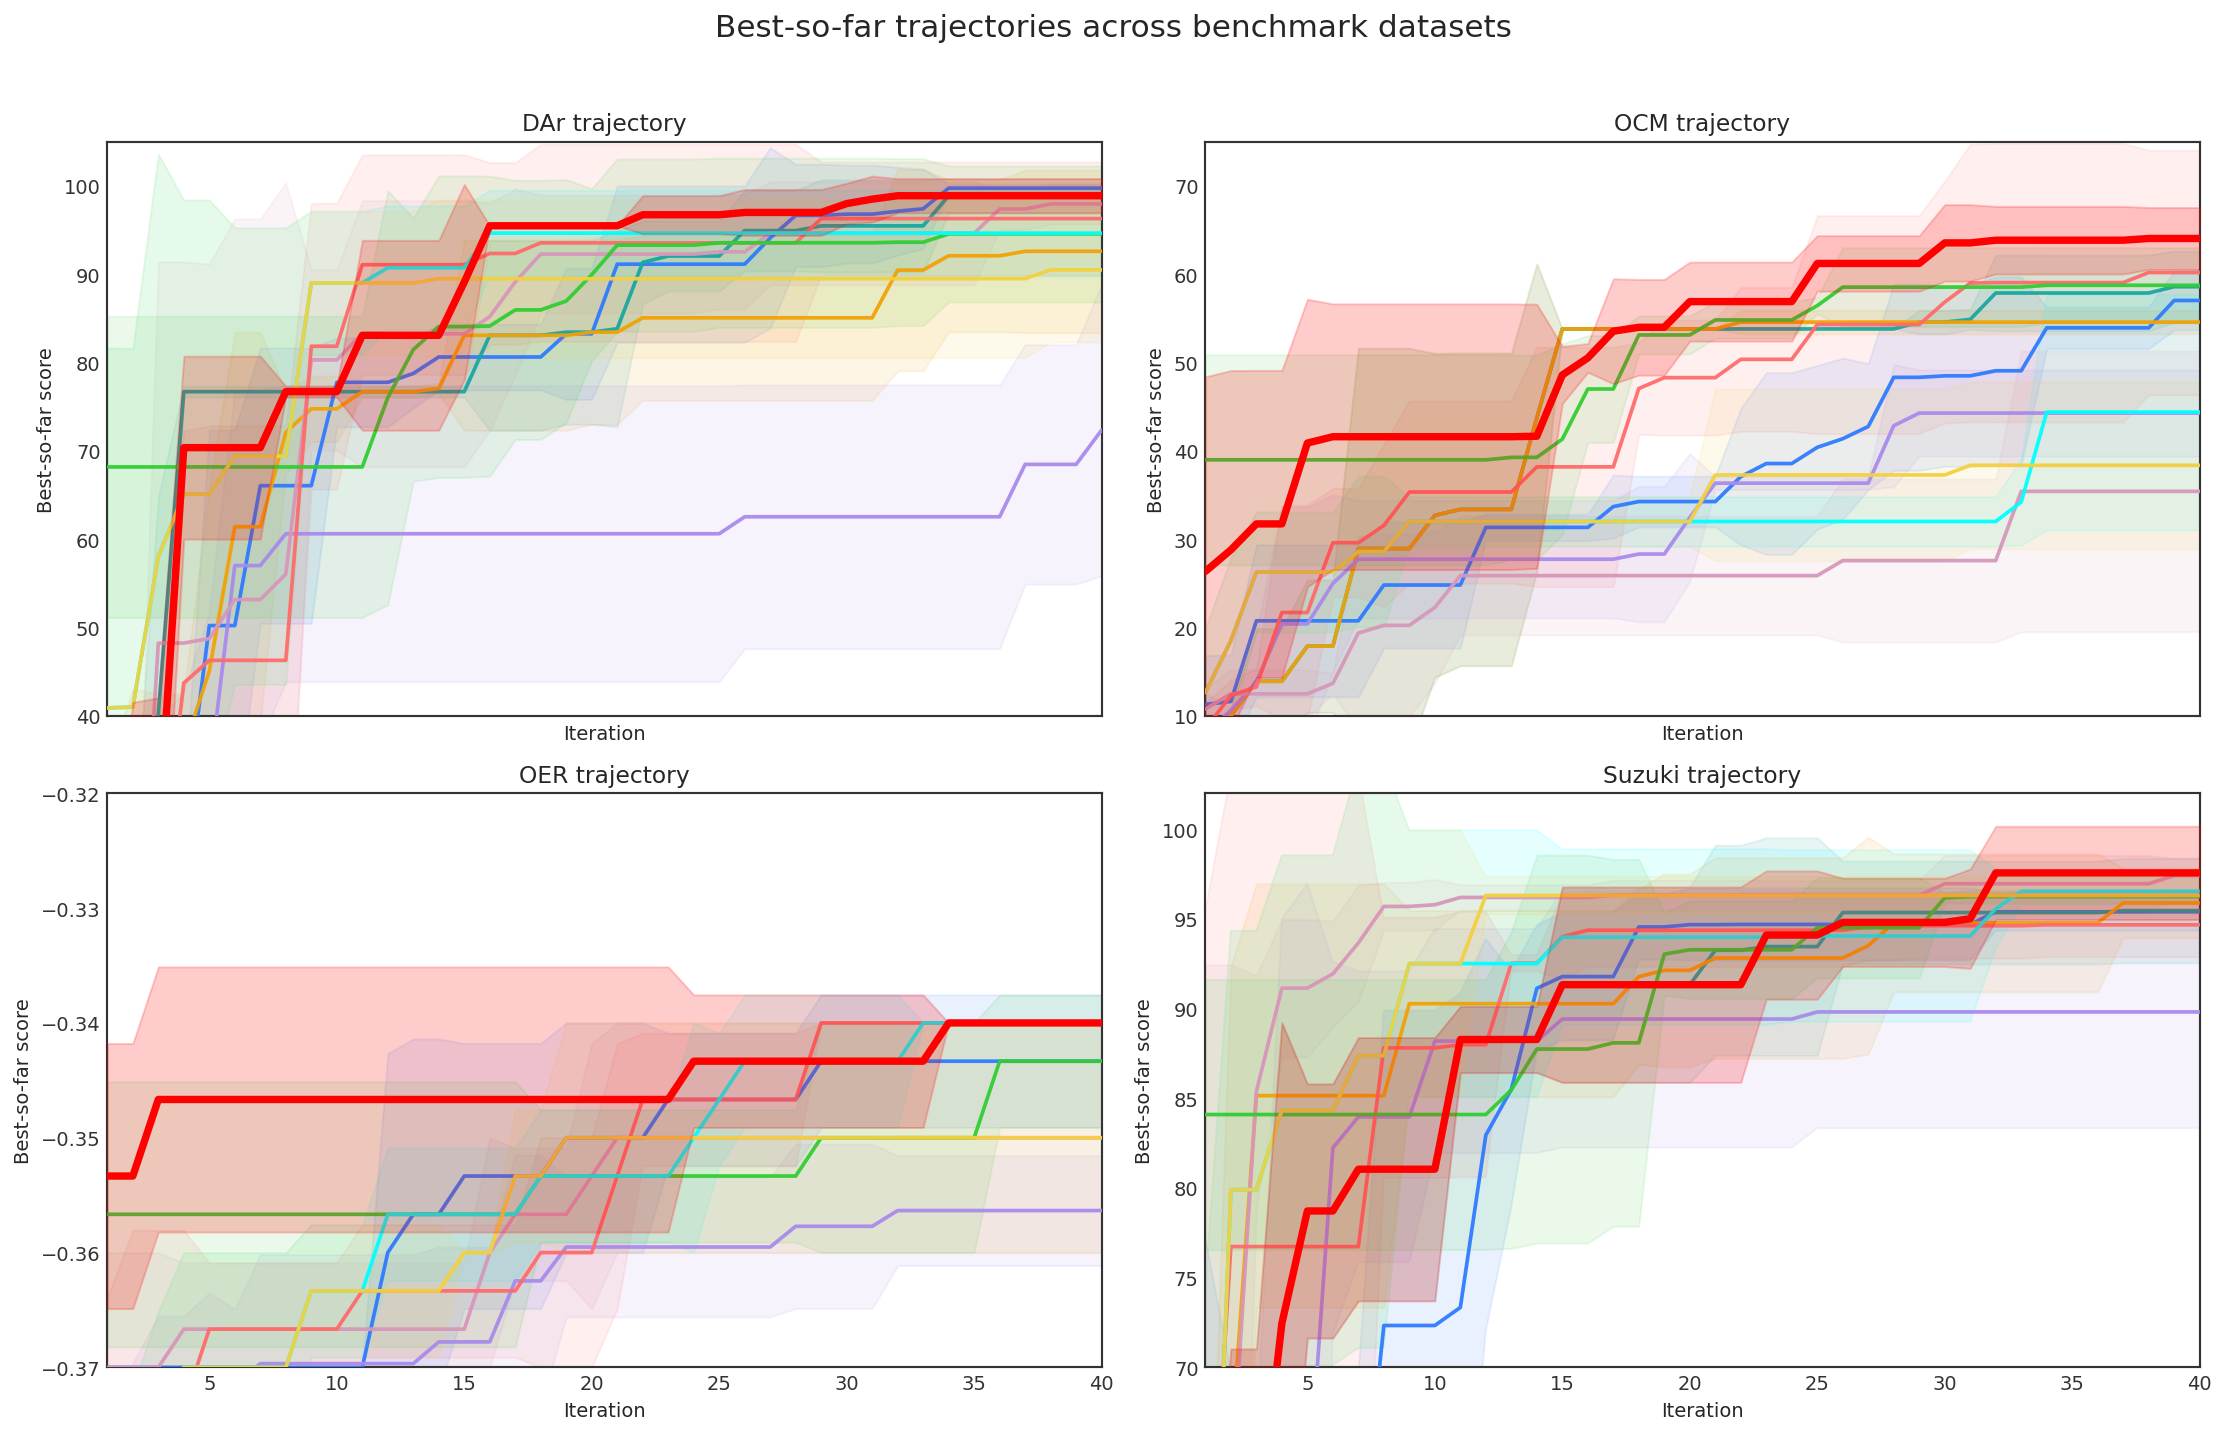

,method,mean,std,n,dataset
0,Reasoning BO,99.740000,0.450333,3,DAR
1,ChemBO,98.880000,1.939897,3,DAR
2,Pure AutoBO,98.880000,1.939897,3,DAR
3,BORA,97.953333,2.290007,3,DAR
4,CAKE,96.290000,6.408596,3,DAR


In [15]:
AXIS_LIMITS = {
    # Example:
    'OER': {'xlim': (1, 40), 'ylim': (-0.37, -0.32)},
    'DAR': {'xlim': (1, 40), 'ylim': (40, 105)},
    'OCM': {'ylim': (10, 75)},
    'Suzuki': {'ylim': (70, 102)},
}

final_summary_df = plot_bsf_trajectories(
    CSV_PATHS,
    axis_limits=AXIS_LIMITS,
    figsize=(16, 10),
    sharex=True,
    colors=MACARON_METHOD_COLORS,
    chembo_linewidth=3.8,
    other_linewidth=1.9,
    save_legend=True,
    save_individual=True,
)

final_summary_df.head()




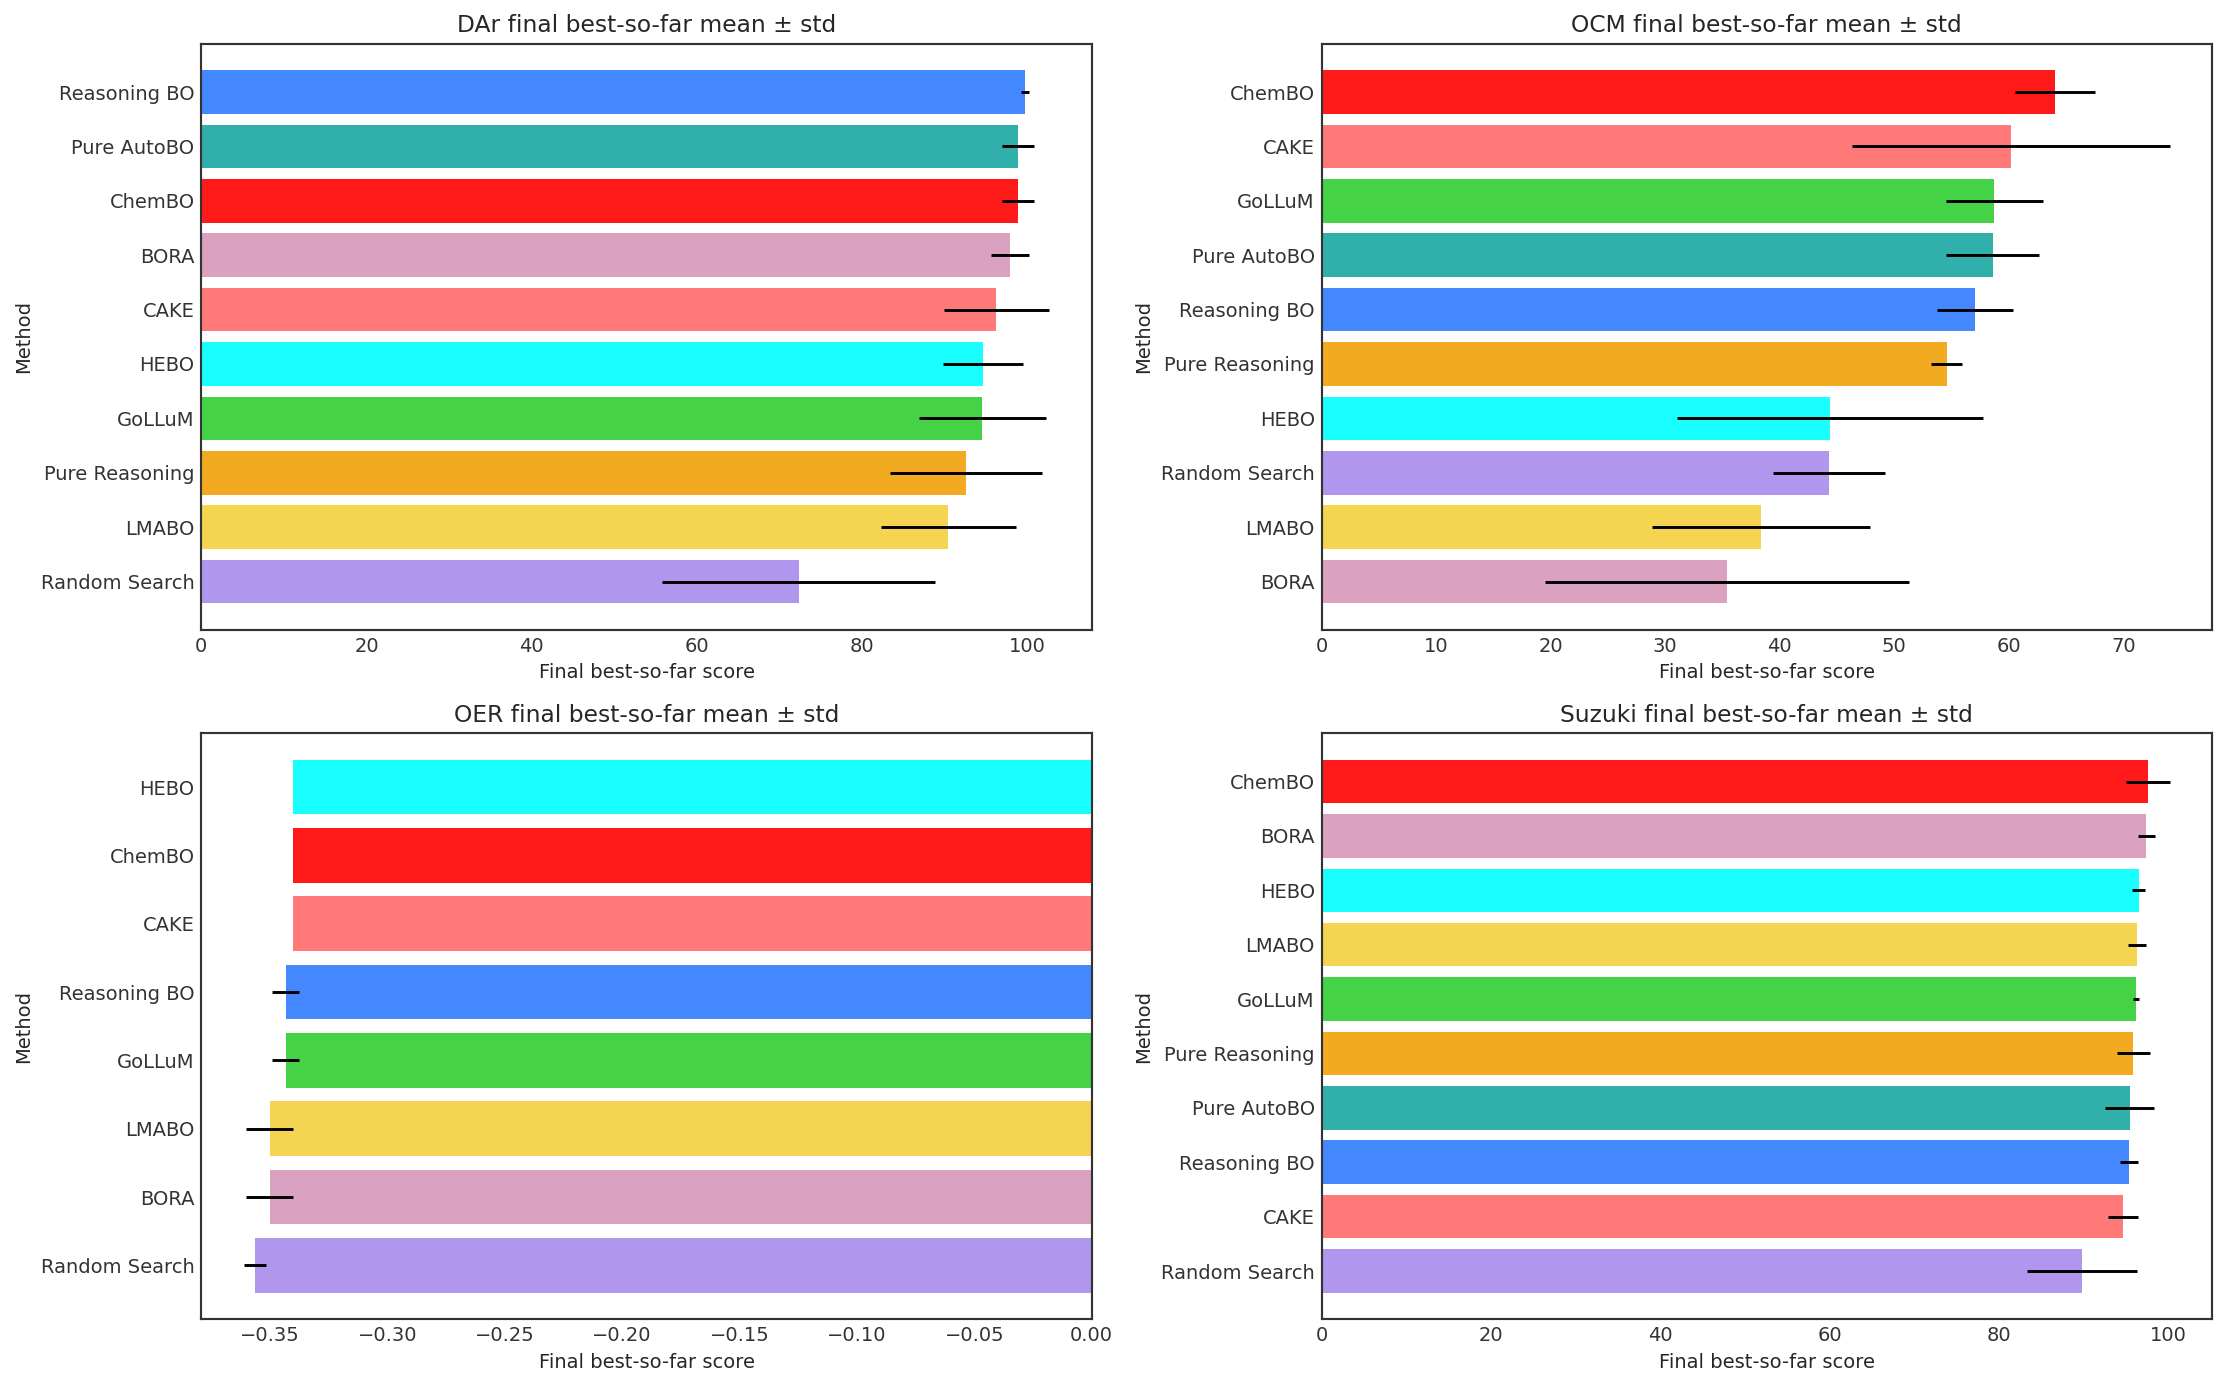

,method,mean,std,n,dataset
0,Reasoning BO,99.740000,0.450333,3,DAR
1,ChemBO,98.880000,1.939897,3,DAR
2,Pure AutoBO,98.880000,1.939897,3,DAR
3,BORA,97.953333,2.290007,3,DAR
4,CAKE,96.290000,6.408596,3,DAR
5,HEBO,94.643333,4.844382,3,DAR
6,GoLLuM,94.558000,7.705785,5,DAR
7,Pure Reasoning,92.586667,9.207504,3,DAR
8,LMABO,90.483333,8.162869,3,DAR
9,Random Search,72.346667,16.509459,3,DAR


In [16]:
final_best_table = plot_final_best_bar_panels(
    final_summary_df,
    colors=MACARON_METHOD_COLORS,
    figsize=(16, 10),
    save_individual=True,
)

final_best_table



## AF / EF Plots

- `EF = Y_incumbent / Y_best` for datasets with positive best values.
- For datasets like `OER` whose best value is non-positive, the notebook defaults to a shifted version before taking the ratio so EF stays interpretable.
- `AF = AUC_method / AUC_random_search`, where `AUC` is computed from the mean best-so-far trajectory.


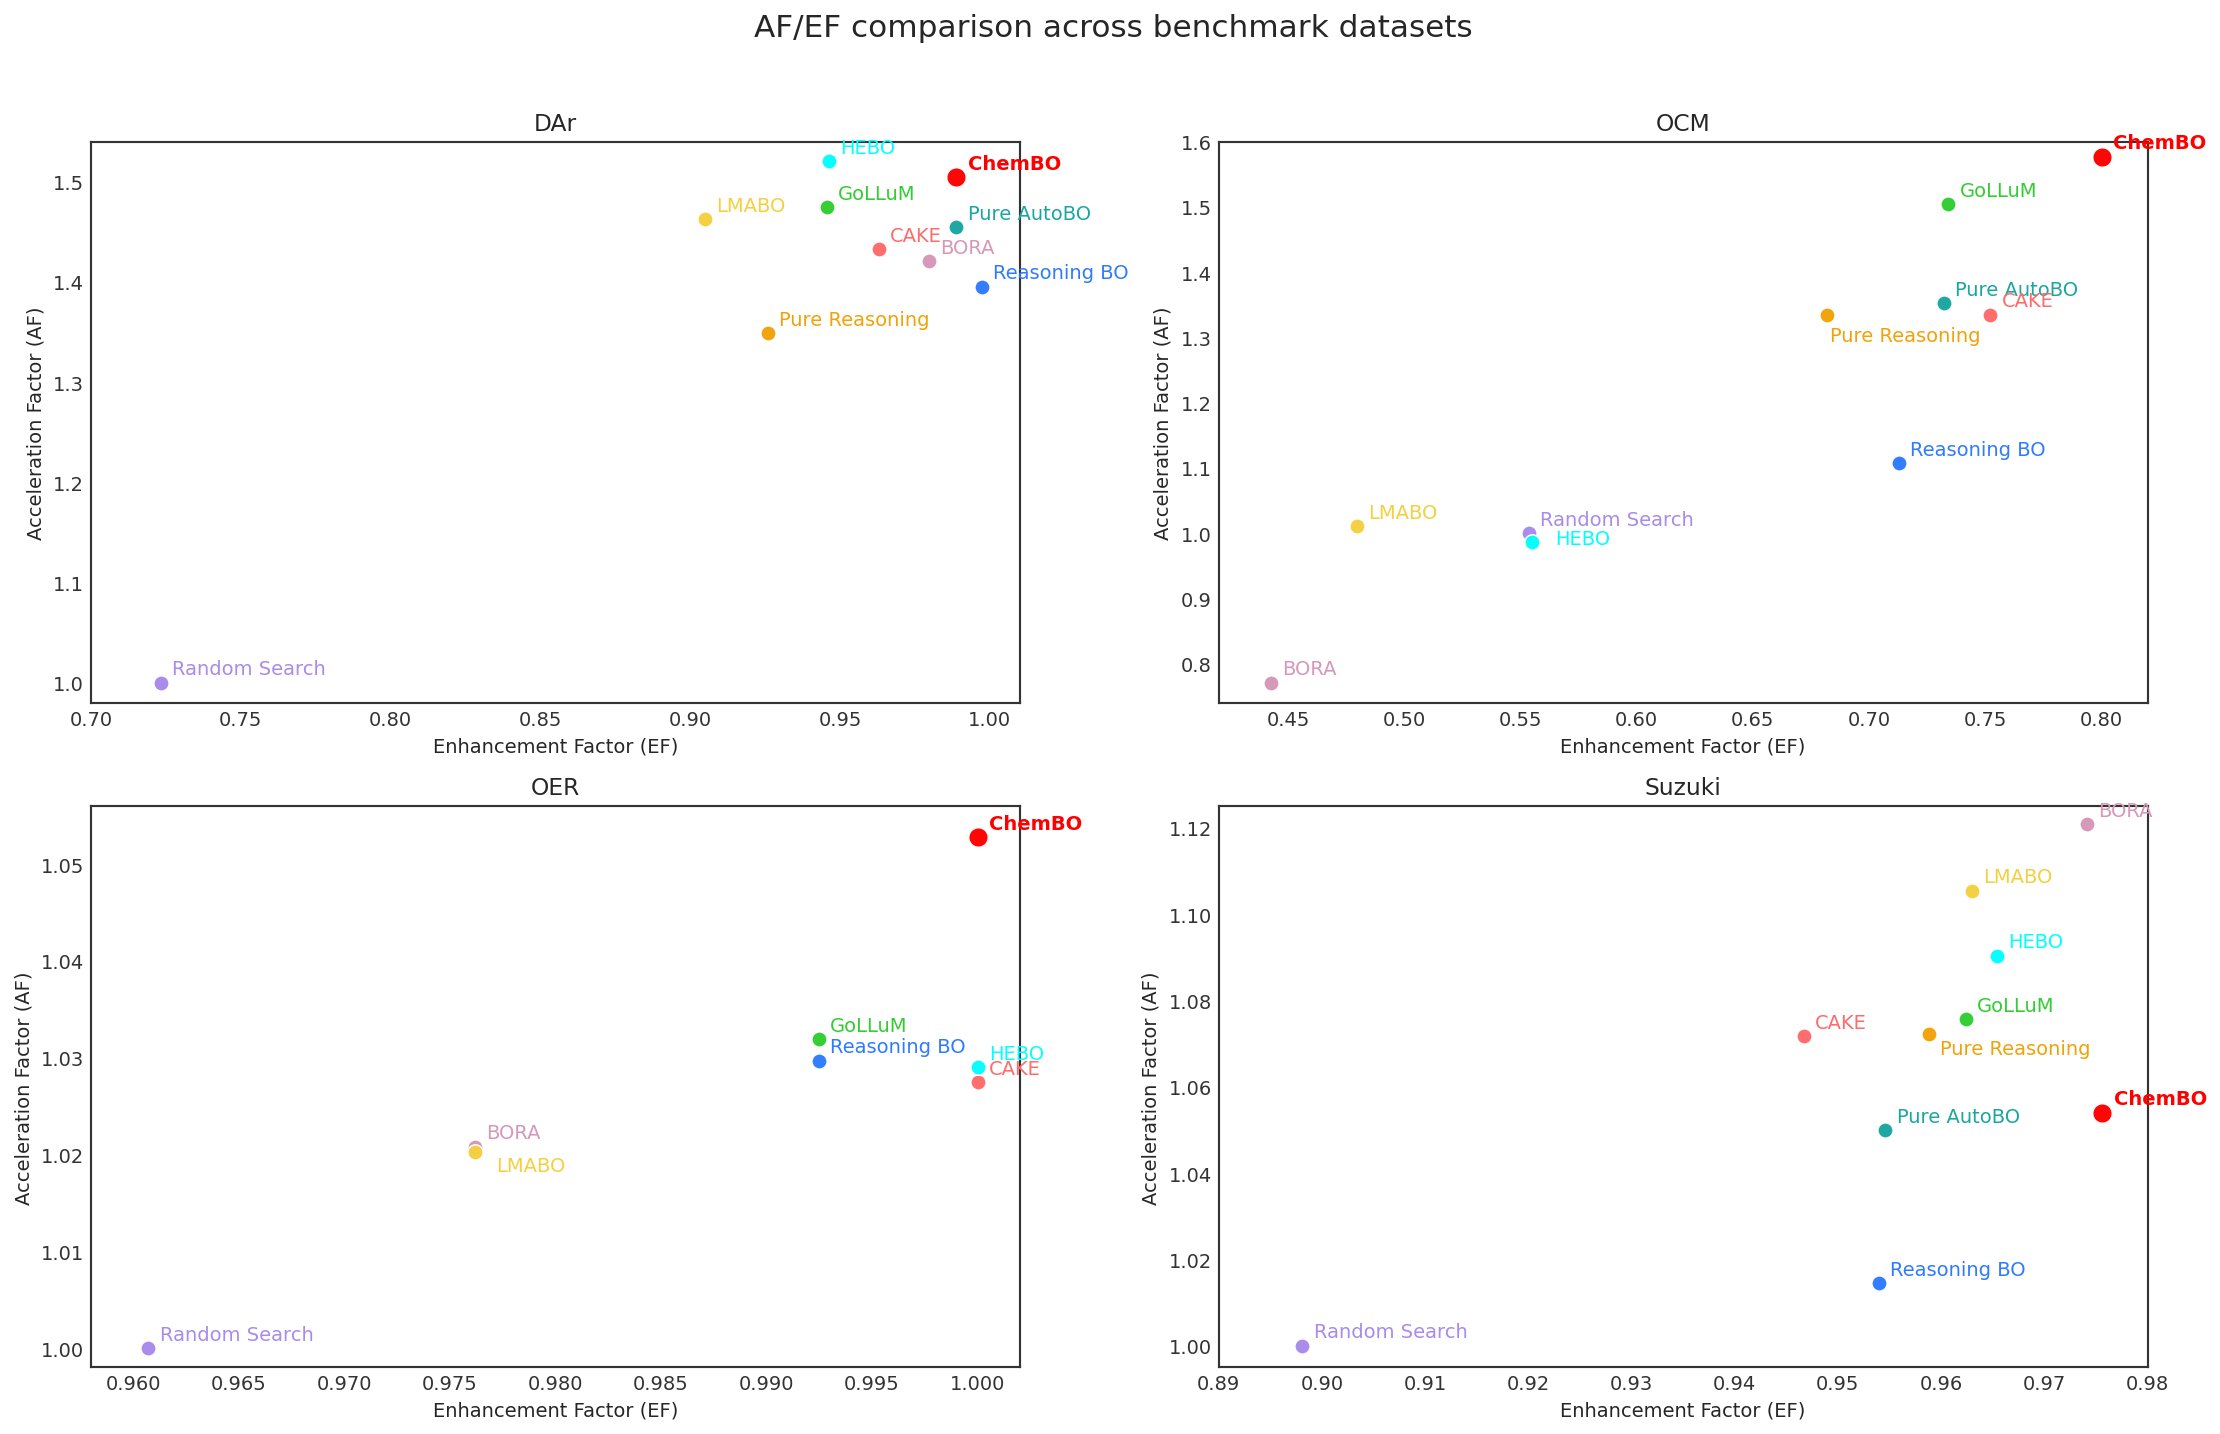

,dataset,method,raw_final_incumbent,final_incumbent,dataset_best,dataset_min,value_shift,auc,af,ef,ef_mode
0,DAR,HEBO,94.643333,94.643333,100.000000,0.000000,0.00,3406.531667,1.520361,0.946433,shifted_dataset_values
1,DAR,ChemBO,98.880000,98.880000,100.000000,0.000000,0.00,3371.165000,1.504577,0.988800,shifted_dataset_values
2,DAR,GoLLuM,94.558000,94.558000,100.000000,0.000000,0.00,3304.255000,1.474714,0.945580,shifted_dataset_values
3,DAR,LMABO,90.483333,90.483333,100.000000,0.000000,0.00,3276.798333,1.462460,0.904833,shifted_dataset_values
4,DAR,Pure AutoBO,98.880000,98.880000,100.000000,0.000000,0.00,3259.543333,1.454759,0.988800,shifted_dataset_values
5,DAR,CAKE,96.290000,96.290000,100.000000,0.000000,0.00,3210.548333,1.432892,0.962900,shifted_dataset_values
6,DAR,BORA,97.953333,97.953333,100.000000,0.000000,0.00,3183.356667,1.420757,0.979533,shifted_dataset_values
7,DAR,Reasoning BO,99.740000,99.740000,100.000000,0.000000,0.00,3126.543333,1.395400,0.997400,shifted_dataset_values
8,DAR,Pure Reasoning,92.586667,92.586667,100.000000,0.000000,0.00,3021.803333,1.348654,0.925867,shifted_dataset_values
9,DAR,Random Search,72.346667,72.346667,100.000000,0.000000,0.00,2240.606667,1.000000,0.723467,shifted_dataset_values


In [17]:
AF_EF_AXIS_LIMITS = {
    'DAR': {'xlim': (0.70, 1.01), 'ylim': (0.98, 1.54)},
    'OCM': {'xlim': (0.42, 0.82), 'ylim': (0.74, 1.60)},
    'OER': {'xlim': (0.958, 1.002), 'ylim': (0.998, 1.056)},
    'Suzuki': {'xlim': (0.89, 0.98), 'ylim': (0.995, 1.125)},
}

AF_EF_LABEL_OFFSETS = {
    # Manually tune any crowded labels here using absolute (dx, dy) offsets.
    # Example:
    'OCM': {
        'HEBO': (0.01, -0.0040),
        'Pure Reasoning': (0.0010, -0.04),
    },
    'OER': {
        'LMABO': (0.001, -0.0020),
    },
    'Suzuki': {
        'Pure Reasoning': (0.0010, -0.0045),
    },
}

af_ef_df = compute_af_ef_table(
    CSV_PATHS,
    reference_method='Random Search',
    ef_mode='shifted_dataset_values',
)

plot_af_ef_scatter(
    af_ef_df,
    axis_limits=AF_EF_AXIS_LIMITS,
    figsize=(16, 10),
    colors=MACARON_METHOD_COLORS,
    annotate=True,
    include_random_search=True,
    save_individual=True,
    label_offsets=AF_EF_LABEL_OFFSETS,
    default_label_offset_frac=(0.012, 0.015),
)

summarize_af_ef(af_ef_df)



